# AUPIMO

Basic usage of the metric AUPIMO (pronounced "a-u-pee-mo").


# What is AUPIMO?

The `Area Under the Per-Image Overlap [curve]` (AUPIMO) is a metric of recall (higher is better) designed for visual anomaly detection.

Inspired by the [ROC](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) and [PRO](https://link.springer.com/article/10.1007/s11263-020-01400-4) curves, 

> AUPIMO is the area under a curve of True Positive Rate (TPR or _recall_) as a function of False Positive Rate (FPR) restricted to a fixed range. 

But:
- the TPR (Y-axis) is *per-image* (1 image = 1 curve/score);
- the FPR (X-axis) considers the (average of) **normal** images only; 
- the FPR (X-axis) is in log scale and its range is [1e-5, 1e-4]\* (harder detection task!).

\* The score (the area under the curve) is normalized to be in [0, 1].

AUPIMO can be interpreted as

> average segmentation recall in an image given that the model (nearly) does not yield false positives in normal images.

References in the last cell.

![AUROC vs. AUPRO vs. AUPIMO](./roc_pro_pimo.svg)

# Setup

Install `anomalib` using `pip`.

In [ ]:
# TODO(jpcbertoldo): replace by `pip install anomalib` when AUPIMO is released  # noqa: TD003
%pip install ../../..

Change the directory to have access to the datasets.

In [ ]:
from pathlib import Path
print("current working directory:", Path.cwd())
# NOTE: Provide the path to the dataset root directory.
#   If the datasets is not downloaded, it will be downloaded
#   to this directory.
dataset_root = Path.cwd().parent.parent/ "datasets" / "MVTecAD"
print(f"Dataset root directory: {dataset_root}")

current working directory: /home/admin_rech/repos/anomalib/examples/04_metrics
Dataset root directory: /home/admin_rech/repos/anomalib/datasets/MVTecAD


## Imports

In [ ]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
from scipy import stats
from anomalib.data import MVTecAD
from anomalib.engine import Engine
from anomalib.metrics import AUPIMO, Evaluator
from anomalib.models import Padim

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
%matplotlib inline

## Data Module

We will use dataset Leather from MVTec AD. 

> See the notebooks below for more details on datamodules. 
> [github.com/open-edge-platform/anomalib/tree/main/examples/notebooks/02_data](https://github.com/open-edge-platform/anomalib/tree/main/examples/notebooks/02_data)

In [5]:
datamodule = MVTecAD(
    root=dataset_root,
    category="leather",
    train_batch_size=32,
    eval_batch_size=32,
    num_workers=8,
)

# Average AUPIMO (Basic)

The easiest way to use AUPIMO is by creating the metric and setting it as the test metric in a new Evaluator. The evaluator will be attached to the model in the next step.

By default, the average AUPIMO is calculated.

In [6]:
aupimo = AUPIMO()
evaluator = Evaluator(test_metrics=aupimo)

Metric `AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


## Model

We will use `PaDiM` (performance is not the best, but it is fast to train).

> See the notebooks below for more details on models. 
> [github.com/open-edge-platform/anomalib/tree/main/examples/notebooks/03_models](https://github.com/open-edge-platform/anomalib/tree/main/examples/notebooks/03_models)

Instantiate the model and add the `Evaluator` instance which we created in the previous step.

In [7]:
model = Padim(
    # only use one layer to speed it up
    layers=["layer1"],
    n_features=64,
    backbone="resnet18",
    pre_trained=True,
    evaluator=evaluator,
)

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.


In [8]:
engine = Engine(
    accelerator="auto",  # \<"cpu", "gpu", "tpu", "ipu", "hpu", "auto">,
    devices=1,
    logger=False,
)
engine.fit(datamodule=datamodule, model=model)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
You are using a CUDA device ('NVIDIA RTX PRO 2000 Blackwell Generation Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  157 K │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 157 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 157 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 25                                                                                           
Total FLOPs: 0

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/home/admin_rech/micromamba/envs/anomalib/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 25 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


`Trainer.fit` stopped: `max_epochs=1` reached.


In [9]:
# will output the AUPIMO score on the test set
engine.test(datamodule=datamodule, model=model)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          AUPIMO           │    0.7427706604035922     │
└───────────────────────────┴───────────────────────────┘

[{'AUPIMO': 0.7427706604035922}]

# Individual AUPIMO Scores (Detailed)

AUPIMO assigns one recall score per anomalous image in the dataset.

It is possible to access each of the individual AUPIMO scores and look at the distribution.

Collect the predictions and the ground truth.

In [10]:
predictions = engine.predict(dataloaders=datamodule.test_dataloader(), model=model, return_predictions=True)

ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

Compute the AUPIMO scores.

In [11]:
aupimo = AUPIMO(
    # with `False` all the values are returned in a dataclass
    return_average=False,
)

for batch in predictions:
    aupimo.update(batch)

Metric `AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


In [12]:
# `pimo_result` has the PIMO curves of each image
# `aupimo_result` has the AUPIMO values
#     i.e. their Area Under the Curve (AUC)
pimo_result, aupimo_result = aupimo.compute()

Check the outputs.

In [13]:
# the `nan`s are the normal images; they do not
# have a score because recall is not defined for them
print(aupimo_result.aupimos)

tensor([1.0000, 0.9144, 0.4943, 0.2832, 0.2785, 0.8688, 1.0000, 0.7427, 0.2900,
        0.8996, 1.0000, 0.9144, 0.6390, 0.9425, 0.9583, 0.9391, 0.9889, 0.5133,
        0.9698, 0.9236, 0.5732, 0.4620, 0.9996, 0.9078, 0.5879, 1.0000, 1.0000,
        1.0000, 0.3779, 0.6754, 0.4217, 0.9300, 0.7756, 0.4304, 0.8335, 0.9296,
        0.9992, 0.5582, 0.9937, 0.7813, 0.4990, 0.7633, 0.5362, 0.7159, 0.1684,
        0.3087, 0.3599, 0.2428, 0.2882, 0.6407, 0.5572, 0.3277, 0.7749, 0.6741,
        0.5516, 1.0000, 0.2401, 0.9719, 0.5348, 0.4715, 1.0000, 0.9730, 0.8460,
        0.8865, 0.0606, 0.0000, 0.5257, 0.0000, 1.0000, 1.0000, 1.0000, 0.0088,
        0.9707, 1.0000,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
           nan,    nan,    nan,    nan,    nan,    nan,    nan, 0.9893, 0.8526,
        0.9983, 0.9463, 1.0000, 1.0000, 

## Statistics

Compute statistics of the AUPIMO scores.

In [14]:
# ignore removing the `nan`s
isnan = torch.isnan(aupimo_result.aupimos)

print(f"MEAN\n{aupimo_result.aupimos[~isnan].mean().item()=}")
print(f"OTHER STATISTICS\n{stats.describe(aupimo_result.aupimos[~isnan])}")

MEAN
aupimo_result.aupimos[~isnan].mean().item()=0.7427706604035922
OTHER STATISTICS
DescribeResult(nobs=np.int64(92), minmax=(np.float64(0.0), np.float64(1.0)), mean=np.float64(0.7427706604035924), variance=np.float64(0.08756186445016054), skewness=np.float64(-0.927973169876051), kurtosis=np.float64(-0.3312511348725242))


## Plot

Visualize the distribution of the AUPIMO scores.

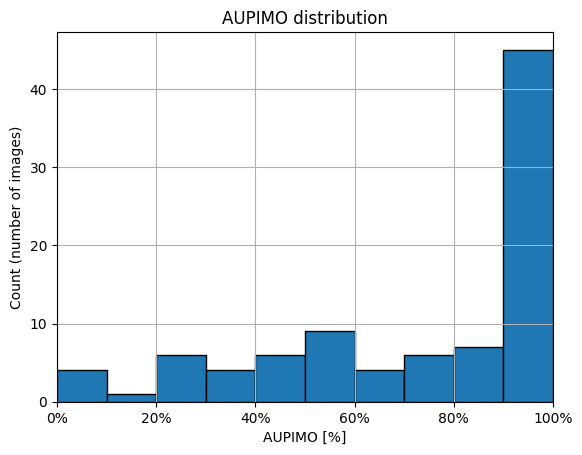

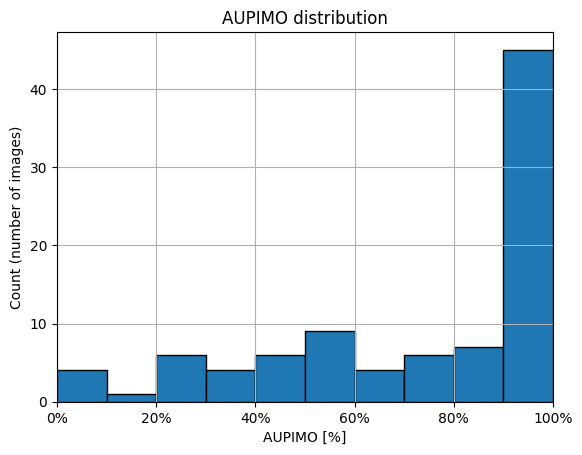

In [15]:
fig, ax = plt.subplots()
ax.hist(aupimo_result.aupimos.numpy(), bins=np.linspace(0, 1, 11), edgecolor="black")
ax.set_ylabel("Count (number of images)")
ax.yaxis.set_major_locator(MaxNLocator(5, integer=True))
ax.set_xlim(0, 1)
ax.set_xlabel("AUPIMO [%]")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid()
ax.set_title("AUPIMO distribution")
fig  # noqa: B018, RUF100

# Cite Us

AUPIMO was developed during Google Summer of Code 2023 (GSoC 2023) with the `anomalib` team from OpenVINO Toolkit.

Our work was accepted to the British Machine Vision Conference 2024 (BMVC 2024).

```bibtex
@misc{bertoldo2024aupimo,
      title={{AUPIMO: Redefining Visual Anomaly Detection Benchmarks with High Speed and Low Tolerance}}, 
      author={Joao P. C. Bertoldo and Dick Ameln and Ashwin Vaidya and Samet Akçay},
      year={2024},
      eprint={2401.01984},
      archivePrefix={arXiv},
      primaryClass={cs.CV},
      url={https://arxiv.org/abs/2401.01984}, 
}
```

Paper on arXiv: [arxiv.org/abs/2401.01984](https://arxiv.org/abs/2401.01984) (accepted to BMVC 2024)

Medium post: [medium.com/p/c653ac30e802](https://medium.com/p/c653ac30e802)

Official repository: [github.com/jpcbertoldo/aupimo](https://github.com/jpcbertoldo/aupimo) (numpy-only API and numba-accelerated versions available)

GSoC 2023 page: [summerofcode.withgoogle.com/archive/2023/projects/SPMopugd](https://summerofcode.withgoogle.com/archive/2023/projects/SPMopugd)